#Regressão com árvore de decisão

O precursor do "Random Forest".

Precisamos separar o domínio do das features em porções, de forma a definir uma árvore de decisão, como no exemplo abaixo:

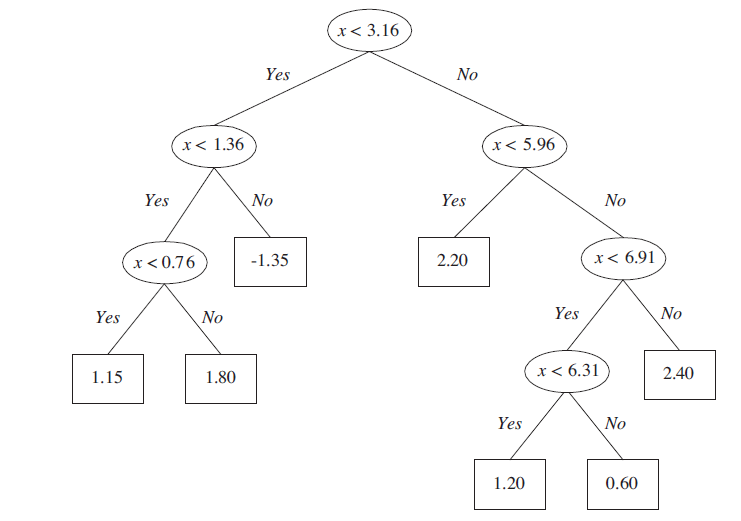

A árvore é separa em nós de decisão e nós folha.

Outra nomenclatura importante é a de nó pai, nós raiz e nós filhos.

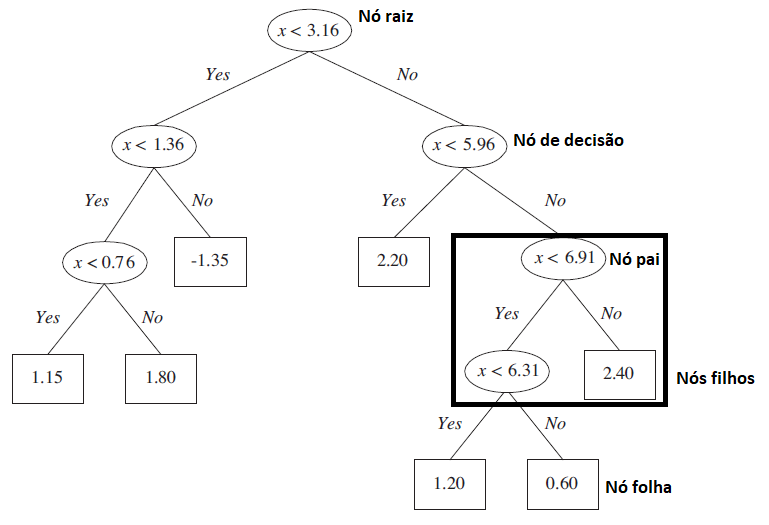

Essas separações são dependentes do valor da variáveis dependente (target). A separação é feita, no caso de árvore de decisão para regressão, utilizando o conceito de variância.

Depois de separado, um ponto qualquer entra na árvore de decisão e seu valor será a média da seção, obtida no nó folha.


A divisão é recursiva (depende da divisão anterior). Maximiza o ganho de informação, que se dá pela minimização da redução da variância.

Por ser recursivo, não achará a árvore de decisão ótima no conceito global.

Também não é necessária a realização de scaling. Por quê?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#import seaborn as sns

#from sklearn.impute import SimpleImputer
#from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import OneHotEncoder
#from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor

from sklearn import tree



In [2]:
path = 'https://raw.githubusercontent.com/OrlandoIFPR/ml2/refs/heads/main/Dataframes/'

In [3]:
dataset = pd.read_csv(path+ 'Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [4]:
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


##Treinamento

In [5]:
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(X, y)

DecisionTreeRegressor(random_state=0)

##Teste e visualização

In [8]:
regressor.predict([[6.5]])

array([150000.])

/tmp/ipykernel_5400/689633856.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


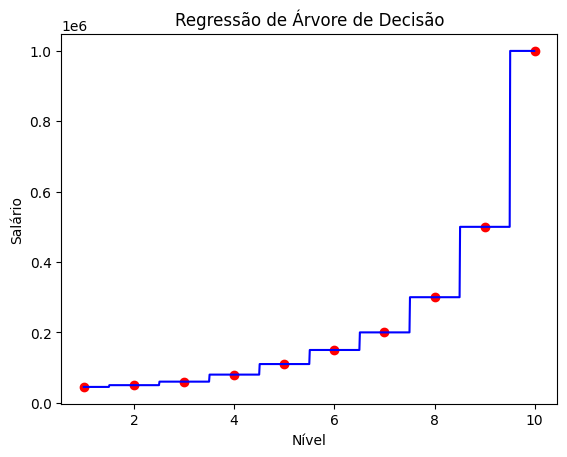

In [9]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, regressor.predict(X_grid), color = 'blue')
plt.title('Regressão de Árvore de Decisão')
plt.xlabel('Nível')
plt.ylabel('Salário')
plt.show()

Overfitting!

In [10]:
regressor = DecisionTreeRegressor(max_depth=4,random_state = 0)
regressor.fit(X, y)

DecisionTreeRegressor(max_depth=4, random_state=0)

In [11]:
regressor.predict([[6.5]])

array([150000.])

/tmp/ipykernel_5400/689633856.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


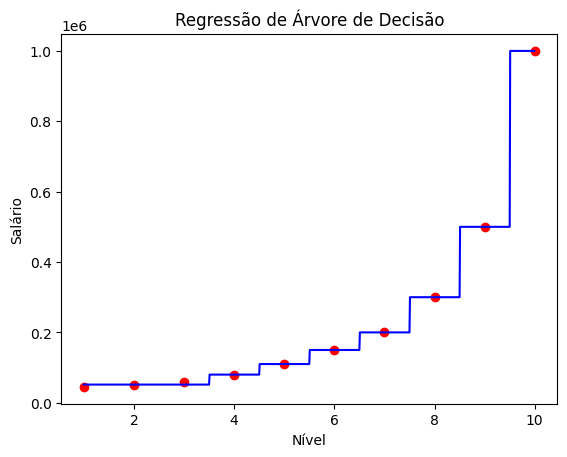

In [12]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, regressor.predict(X_grid), color = 'blue')
plt.title('Regressão de Árvore de Decisão')
plt.xlabel('Nível')
plt.ylabel('Salário')
plt.show()

max_depth é um **hyperparameter**.

Hyperparameters são os parâmetros que podemos passar para a nossa máquina. Cada modelo terá parâmetros diferentes. Para o caso em questão, temos os hyperparameters explicados em:

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html



##Usando o modelo em um dataset maior

In [13]:
dataset = pd.read_csv(path+ 'melb_data.csv')

dataset.head()


,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [14]:
dataset = dataset.dropna(axis=0) #retira as linhas com NaN

features = ['Rooms', 'Bathroom', 'Landsize', 'Distance', 'BuildingArea']


In [24]:
X = dataset[features]
y = dataset.Price

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

regressor2 = DecisionTreeRegressor(max_depth=3,random_state = 0)
regressor2.fit(X_train, y_train)

y_pred = regressor2.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

338357.4219888022

In [22]:
X = dataset[features]
y = dataset.Price

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

regressor2 = DecisionTreeRegressor(max_depth=5,random_state = 0)
regressor2.fit(X_train, y_train)

y_pred = regressor2.predict(X_test)
mean_absolute_error(y_test, y_pred)

256507.56975378355

In [18]:
X = dataset[features]
y = dataset.Price

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

regressor2 = DecisionTreeRegressor(max_depth=10,random_state = 0)
regressor2.fit(X_train, y_train)

y_pred = regressor2.predict(X_test)
mean_absolute_error(y_test, y_pred)

293741.8274304097

In [19]:
features = ['Rooms', 'Bathroom', 'Landsize', 'Distance', 'BuildingArea']

X = dataset[features]
y = dataset.Price

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

regressor2 = DecisionTreeRegressor(max_depth=8,random_state = 0)
regressor2.fit(X_train, y_train)

y_pred = regressor2.predict(X_test)
mean_absolute_error(y_test, y_pred)

283259.70940436644

In [20]:
features = ['Rooms', 'Bathroom', 'Landsize', 'Distance', 'BuildingArea', 'Car', 'YearBuilt','Postcode']

X = dataset[features]
y = dataset.Price

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 0)

regressor2 = DecisionTreeRegressor(max_depth=9,random_state = 0)
regressor2.fit(X_train, y_train)

y_pred = regressor2.predict(X_test)
mean_absolute_error(y_test, y_pred)

221313.08214976254

In [ ]:
y.mean()

1068828.202065849

##Visualização da árvore

https://mljar.com/blog/visualize-decision-tree/

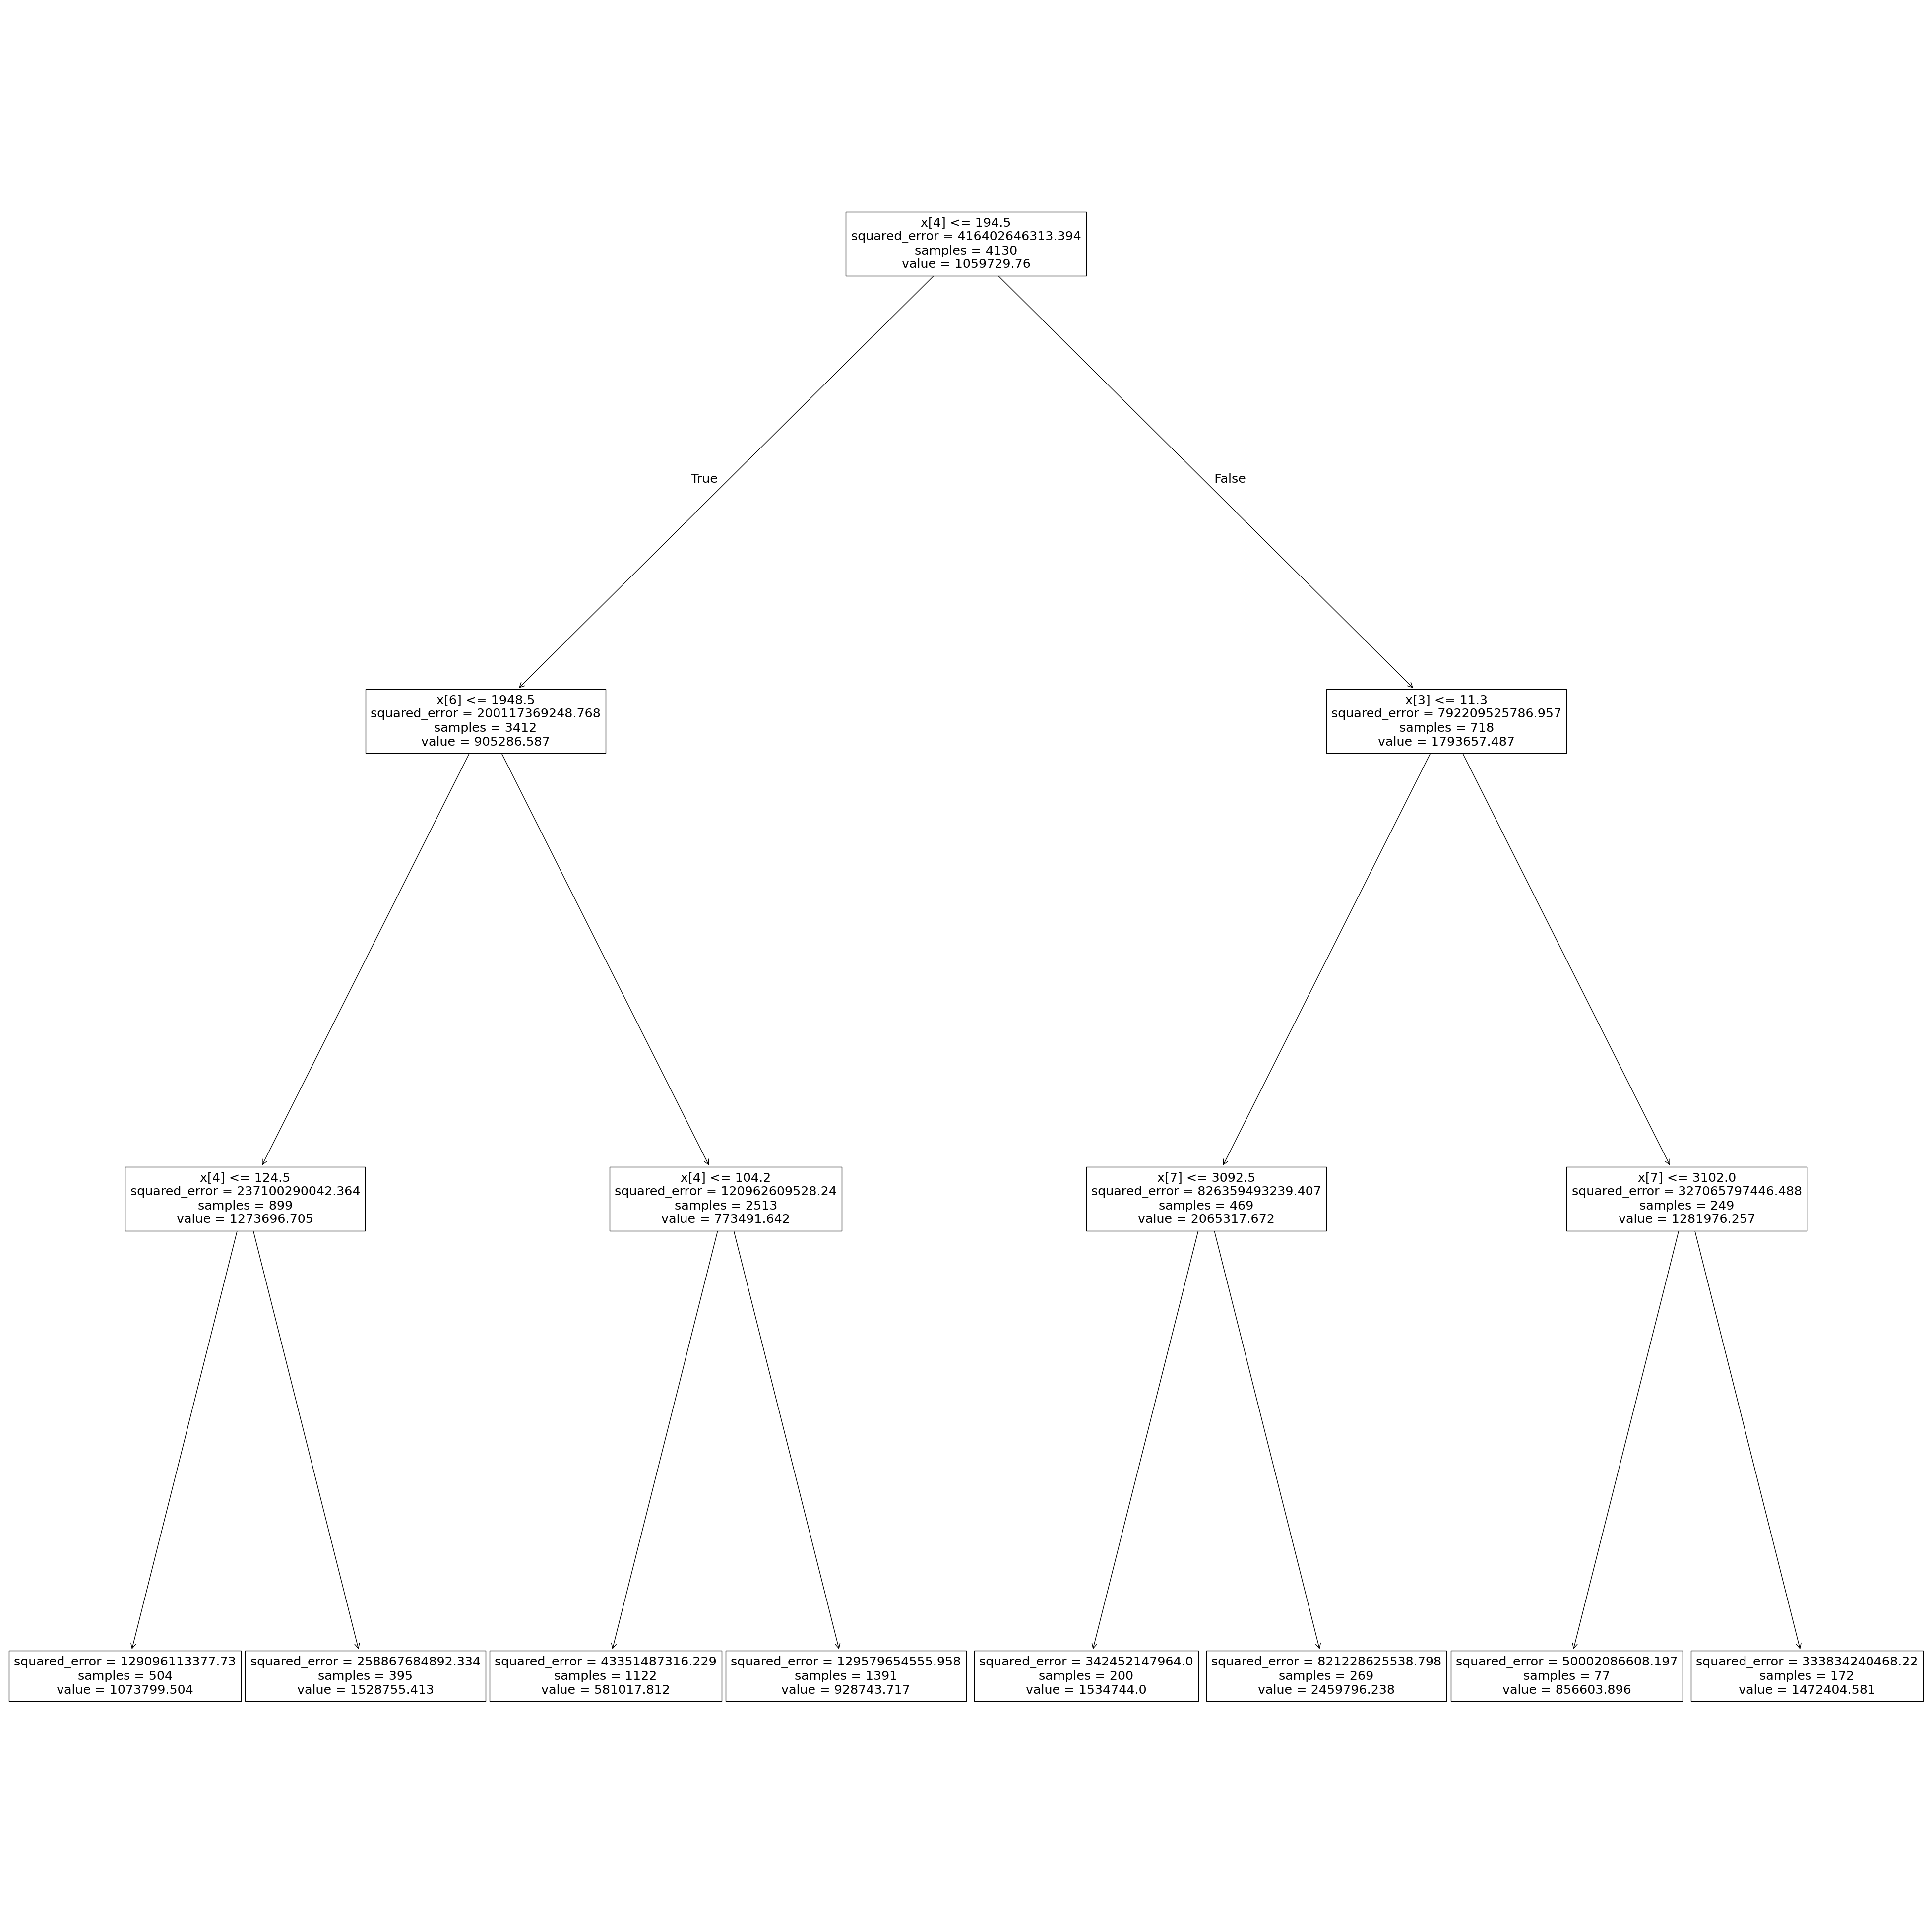

In [25]:
from sklearn import tree

fig = plt.figure(figsize=(50,50))
_ = tree.plot_tree(regressor2)


In [ ]:
#Árvore de decisão em forma de texto
text_representation = tree.export_text(regressor2)
print(text_representation)

|--- feature_4 <= 194.50
|   |--- feature_6 <= 1948.50
|   |   |--- feature_4 <= 124.50
|   |   |   |--- feature_0 <= 2.50
|   |   |   |   |--- feature_4 <= 96.50
|   |   |   |   |   |--- feature_2 <= 33.00
|   |   |   |   |   |   |--- feature_4 <= 63.00
|   |   |   |   |   |   |   |--- feature_3 <= 1.70
|   |   |   |   |   |   |   |   |--- value: [750000.00]
|   |   |   |   |   |   |   |--- feature_3 >  1.70
|   |   |   |   |   |   |   |   |--- feature_4 <= 46.50
|   |   |   |   |   |   |   |   |   |--- value: [298333.33]
|   |   |   |   |   |   |   |   |--- feature_4 >  46.50
|   |   |   |   |   |   |   |   |   |--- value: [513833.33]
|   |   |   |   |   |   |--- feature_4 >  63.00
|   |   |   |   |   |   |   |--- feature_5 <= 1.50
|   |   |   |   |   |   |   |   |--- feature_6 <= 1895.00
|   |   |   |   |   |   |   |   |   |--- value: [935750.00]
|   |   |   |   |   |   |   |   |--- feature_6 >  1895.00
|   |   |   |   |   |   |   |   |   |--- value: [656913.46]
|   |   |   |   |   

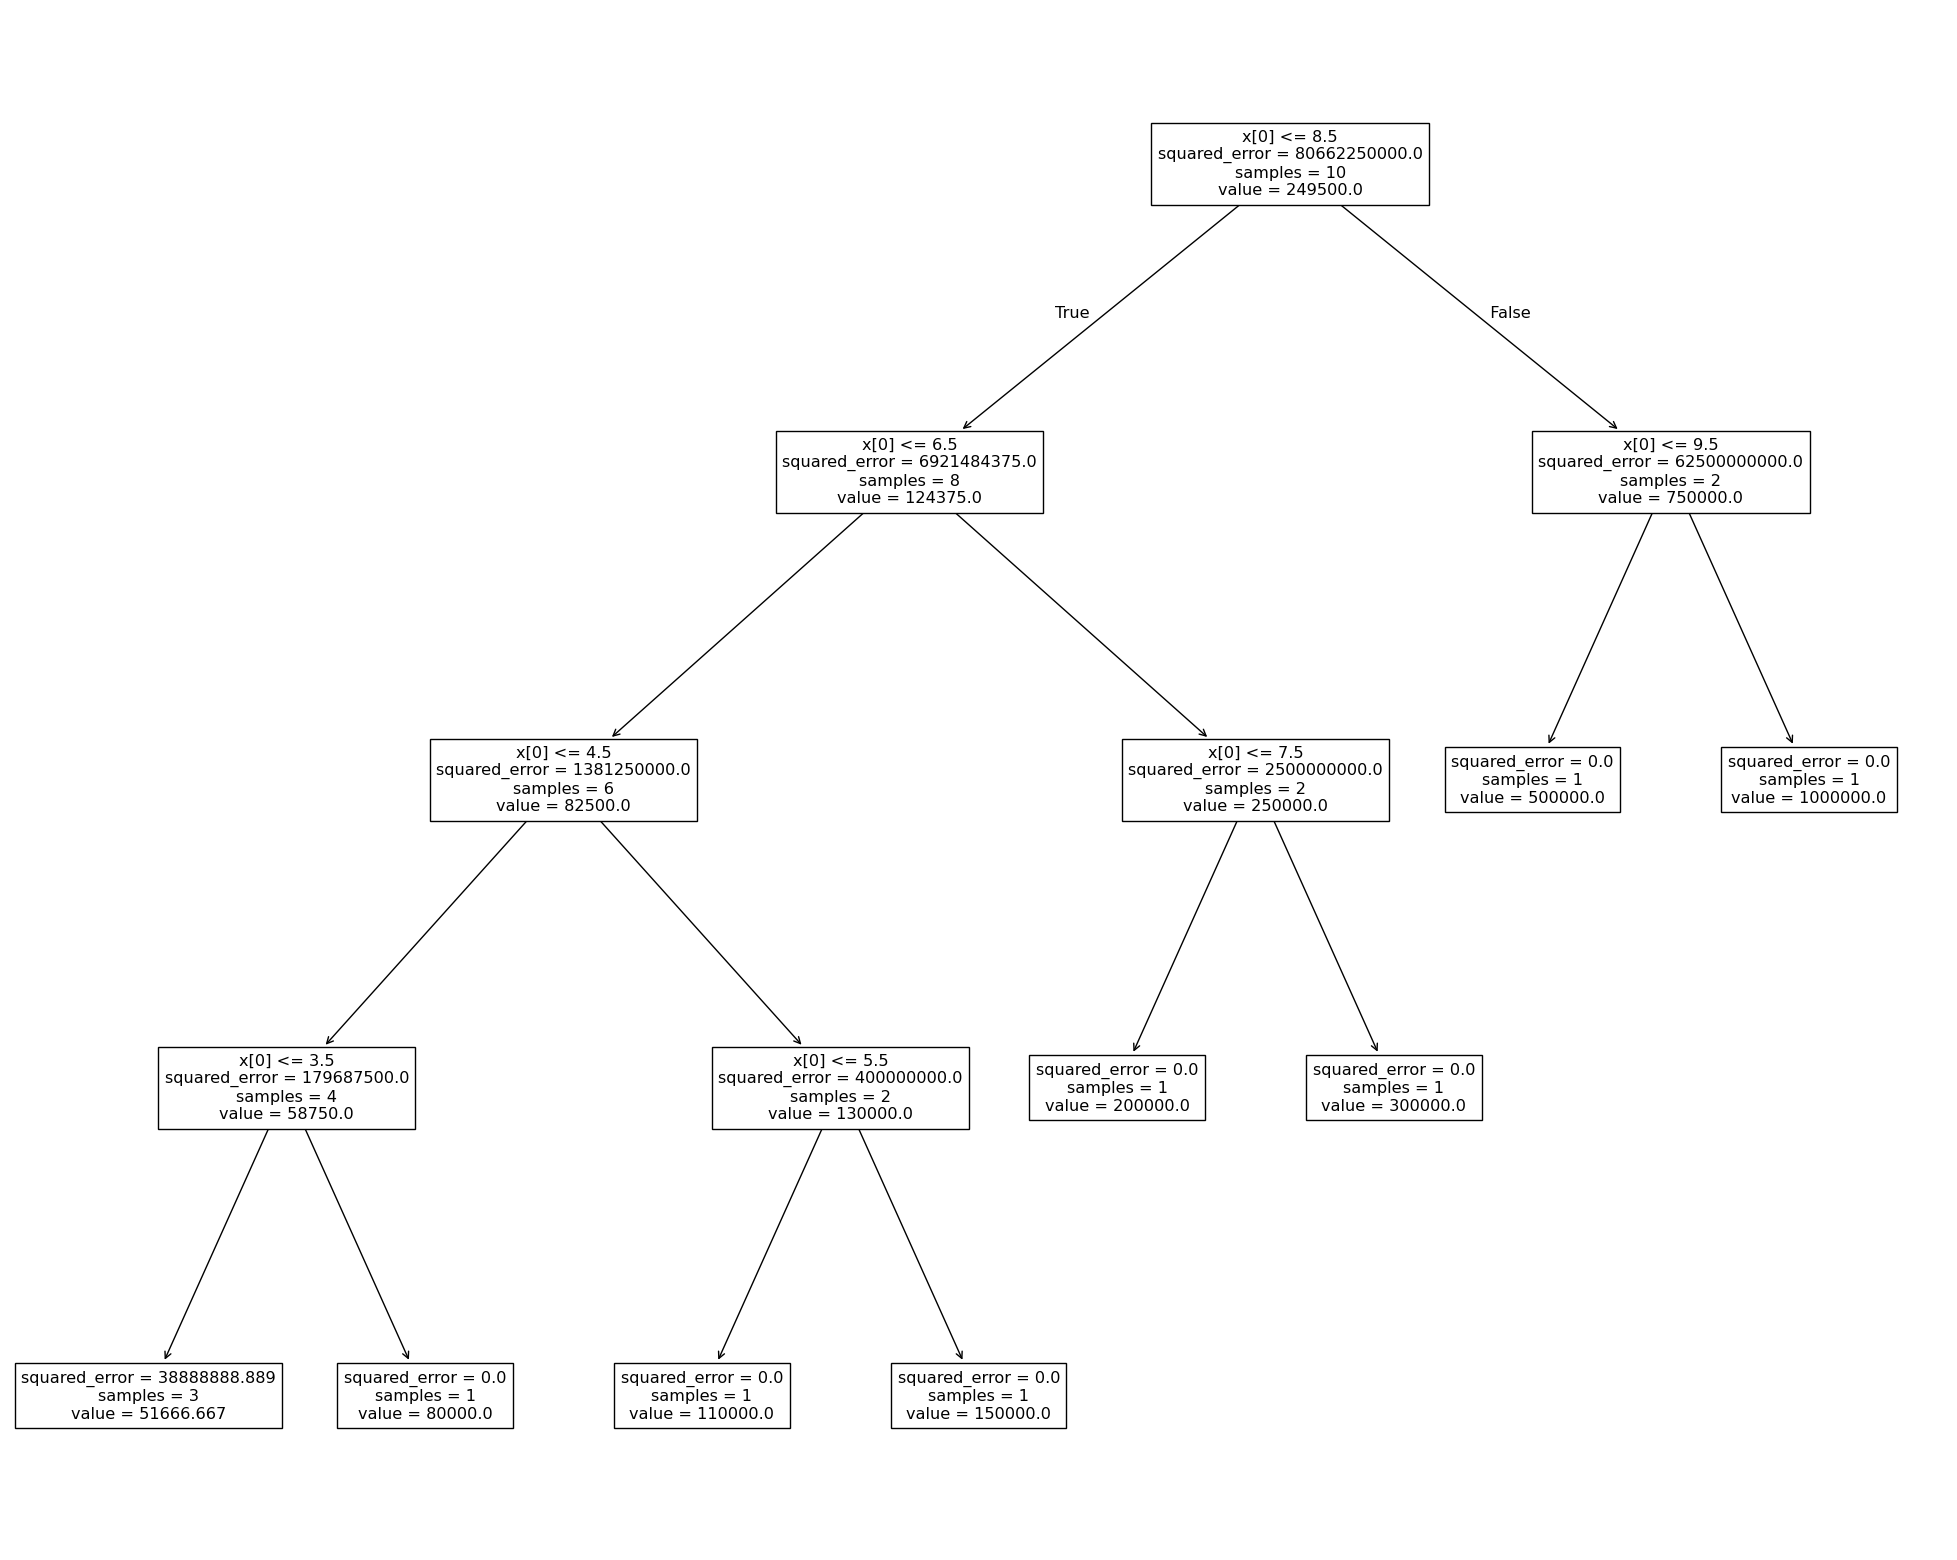

In [ ]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(regressor)

Uma árvore de decisão faz sua própria extração de recursos. A árvore usa apenas as variáveis ​​necessárias e, depois que a árvore é construída, algumas features podem não ser usados. Também podemos dizer que os recursos mais próximos da raiz são mais importantes globalmente. É possível usar uma árvore de decisão para extração de features: construímos uma árvore e então pegamos apenas as features usadas pela árvore como entradas para outro método de aprendizado.

Outra vantagem principal das árvores de decisão é a interpretabilidade: os nós de decisão carregam condições que são simples de entender. Cada caminho da raiz até uma folha corresponde a uma conjunção de testes, pois todas essas condições devem ser satisfeitas para chegar à folha.

